## Final Project Submission

Please fill out:
* Student name: **GROUP 6**
* Student pace: **part time** 
* Scheduled project review date/time: **14/9/25**
* Instructor name: **FIDELIS WANALWENGE**
* Blog post URL:


# **Movie Studio Market Analysis**

## Business Problem
**Film Bros** sees all the big companies creating original video content and they too want to get in on the fun. They have decided to create a new movie studio, but know nothing about creating movies.

## Goal of Analysis
We need to explore what types of films are currently doing the best at the box office. We will then translate those findings into actionable insights that the head of company's movie studio can use to help decide what type of films to create.

## Data sources
We are provided with data from various sources including: IMDB, Box Office Mojo, Rotten Tomatoes, TheMovieDB and The Numbers. The data comes in different file formats, CSV, TSV, as well as a SQLite db.

## Methodology
**1. Data Loading and overview**

**2. Data Cleaning:**
 - Handling Missing values
 - Standardizing column names
 - Dropping duplicates
 - Merging datasets

**3.  Exploratory Data Analysis** so as to find:
 * Overall box office trends
 * Revenue distribution
 * ROI by revenue (Budget vs Revenue )
 * Ratings vs Genres
 * Time Analysis, like seasonal release trends
 
**4. Finding correlations and Relationships**, where we will have our visualizations.

**5. Conclusion**: where we will present our key insights, recommendations, as well as next steps of action for the company.

## 1. Data loading and overview
We will use our data stored in the zippedData folder. We will use pandas to open our CSVs, TSVs as well as to manipulate the sqlite db, using sqlite3 module.

In [1]:
#Importing necessary libraries
import pandas as pd
import sqlite3

In [2]:
#Checking working directory
import os
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'CONTRIBUTING.md', 'index.ipynb', 'LICENSE.md', 'merged_data.csv', 'movie_data_erd.jpeg', 'Phase2Project(Group6).ipynb', 'README.md', 'zippedData']


In [3]:
#Navigating into zippedData
print(os.listdir("zippedData"))

['bom.movie_gross.csv.gz', 'im.db', 'im.db.zip', 'rt.movie_info.tsv.gz', 'rt.reviews.tsv.gz', 'tmdb.movies.csv.gz', 'tn.movie_budgets.csv.gz']


## Connecting to the Database Using sqlite3 + pandas

In [4]:
conn = sqlite3.connect('zippedData\im.db\im.db')

In [5]:
#Creating a DataFrame that contains our table names
df_tables = pd.read_sql("""SELECT name AS table_name
                             FROM sqlite_master 
                            WHERE type = 'table';""", conn)
df_tables

,table_name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


### Having a look at the movie_basics table

In [6]:
#Viewing all coumns of the movie_basics table
df_movie_basics = pd.read_sql("""SELECT *
                                  FROM movie_basics;""", conn)
df_movie_basics

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [7]:
df_movie_basics.describe()

,start_year,runtime_minutes
count,146144.000000,114405.000000
mean,2014.621798,86.187247
std,2.733583,166.360590
min,2010.000000,1.000000
25%,2012.000000,70.000000
50%,2015.000000,87.000000
75%,2017.000000,99.000000
max,2115.000000,51420.000000


In [8]:
df_movie_basics.columns

Index(['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

In [9]:
#Checking primary_title column
df_movie_basics['primary_title']

0                                           Sunghursh
1                     One Day Before the Rainy Season
2                          The Other Side of the Wind
3                                     Sabse Bada Sukh
4                            The Wandering Soap Opera
                             ...                     
146139                            Kuambil Lagi Hatiku
146140    Rodolpho Teóphilo - O Legado de um Pioneiro
146141                                Dankyavar Danka
146142                                         6 Gunn
146143                 Chico Albuquerque - Revelações
Name: primary_title, Length: 146144, dtype: object

In [10]:
#Checking for unique values
df_movie_basics.nunique()

movie_id           146144
primary_title      136071
original_title     137773
start_year             19
runtime_minutes       367
genres               1085
dtype: int64

In [11]:
df_movie_basics['genres'].unique()

array(['Action,Crime,Drama', 'Biography,Drama', 'Drama', ...,
       'Music,Musical,Reality-TV', 'Animation,Crime',
       'Adventure,History,War'], dtype=object)

In [12]:
#GROUP BY for grouping rows
pd.read_sql("""SELECT start_year, genres
                FROM movie_basics
                GROUP BY genres
                ORDER BY start_year ASC;""", conn)

,start_year,genres
0,2010,"Action,Adventure,Crime"
1,2010,"Action,Adventure,Family"
2,2010,"Action,Adventure,Mystery"
3,2010,"Action,Adventure,Thriller"
4,2010,"Action,Adventure,War"
...,...,...
1081,2020,"Romance,Thriller"
1082,2021,"Action,Adventure,Drama"
1083,2021,"Action,Adventure,Fantasy"
1084,2021,"Drama,History,Western"


### Having a look at movie_ratings table

In [13]:
df_movie_ratings = pd.read_sql("""SELECT *
                FROM movie_ratings;""", conn)

In [14]:
#Viewing movies with an average rating greater than 7.0
pd.read_sql("""SELECT *
                FROM movie_ratings
                WHERE averagerating > 7.0
                ORDER BY averagerating DESC;""", conn)

,movie_id,averagerating,numvotes
0,tt5390098,10.0,5
1,tt6295832,10.0,5
2,tt1770682,10.0,5
3,tt2632430,10.0,5
4,tt8730716,10.0,5
...,...,...,...
24640,tt8319662,7.1,8
24641,tt8574252,7.1,1526
24642,tt8954044,7.1,8
24643,tt9471952,7.1,338


In [15]:
pd.read_sql("""SELECT *
                FROM movie_ratings
                WHERE averagerating > 7.0
                GROUP BY numvotes
                HAVING numvotes > 100
                ORDER BY averagerating DESC;""", conn)

,movie_id,averagerating,numvotes
0,tt7131622,9.7,5600
1,tt6058226,9.6,2604
2,tt4131686,9.6,1339
3,tt9343826,9.6,808
4,tt9680166,9.6,624
...,...,...,...
2980,tt3232316,7.1,122
2981,tt8819596,7.1,121
2982,tt7142712,7.1,114
2983,tt3030714,7.1,106


In [16]:
df_tables

,table_name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [17]:
#known_for table
pd.read_sql("""SELECT *
                FROM known_for;""", conn)

,person_id,movie_id
0,nm0061671,tt0837562
1,nm0061671,tt2398241
2,nm0061671,tt0844471
3,nm0061671,tt0118553
4,nm0061865,tt0896534
...,...,...
1638255,nm9990690,tt9090932
1638256,nm9990690,tt8737130
1638257,nm9991320,tt8734436
1638258,nm9991320,tt9615610


In [18]:
#directors table
pd.read_sql("""SELECT *
                FROM directors;""", conn)

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502
...,...,...
291169,tt8999974,nm10122357
291170,tt9001390,nm6711477
291171,tt9001494,nm10123242
291172,tt9001494,nm10123248


In [19]:
#Principals table
pd.read_sql("""SELECT *
                FROM principals;""", conn)

,movie_id,ordering,person_id,category,job,characters
0,tt0111414,1,nm0246005,actor,None,"[""The Man""]"
1,tt0111414,2,nm0398271,director,None,None
2,tt0111414,3,nm3739909,producer,producer,None
3,tt0323808,10,nm0059247,editor,None,None
4,tt0323808,1,nm3579312,actress,None,"[""Beth Boothby""]"
...,...,...,...,...,...,...
1028181,tt9692684,1,nm0186469,actor,None,"[""Ebenezer Scrooge""]"
1028182,tt9692684,2,nm4929530,self,None,"[""Herself"",""Regan""]"
1028183,tt9692684,3,nm10441594,director,None,None
1028184,tt9692684,4,nm6009913,writer,writer,None


In [20]:
#writers table
pd.read_sql("""SELECT *
                FROM writers;""", conn)

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0438973,nm0175726
2,tt0438973,nm1802864
3,tt0462036,nm1940585
4,tt0835418,nm0310087
...,...,...
255868,tt8999892,nm10122246
255869,tt8999974,nm10122357
255870,tt9001390,nm6711477
255871,tt9004986,nm4993825


# Having a look at the csv files

### bom.movie_gross.csv.gz

In [21]:
import csv
#Bom_Movie
bom_movie = pd.read_csv(r'zippedData\bom.movie_gross.csv.gz')
print(bom_movie)

                                            title      studio  domestic_gross  \
0                                     Toy Story 3          BV     415000000.0   
1                      Alice in Wonderland (2010)          BV     334200000.0   
2     Harry Potter and the Deathly Hallows Part 1          WB     296000000.0   
3                                       Inception          WB     292600000.0   
4                             Shrek Forever After        P/DW     238700000.0   
...                                           ...         ...             ...   
3382                                    The Quake       Magn.          6200.0   
3383                  Edward II (2018 re-release)          FM          4800.0   
3384                                     El Pacto        Sony          2500.0   
3385                                     The Swan  Synergetic          2400.0   
3386                            An Actor Prepares       Grav.          1700.0   

     foreign_gross  year  


In [22]:
bom_movie.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [23]:
bom_movie.info

<bound method DataFrame.info of                                             title      studio  domestic_gross  \
0                                     Toy Story 3          BV     415000000.0   
1                      Alice in Wonderland (2010)          BV     334200000.0   
2     Harry Potter and the Deathly Hallows Part 1          WB     296000000.0   
3                                       Inception          WB     292600000.0   
4                             Shrek Forever After        P/DW     238700000.0   
...                                           ...         ...             ...   
3382                                    The Quake       Magn.          6200.0   
3383                  Edward II (2018 re-release)          FM          4800.0   
3384                                     El Pacto        Sony          2500.0   
3385                                     The Swan  Synergetic          2400.0   
3386                            An Actor Prepares       Grav.          1700.0

### tn.movie_budgets.csv.gz

In [24]:
#tn.movie budgets
movie_budget = pd.read_csv(r'zippedData\tn.movie_budgets.csv.gz')

In [25]:
movie_budget

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


### tmdb.movies.csv.gz

In [26]:
#tmdb.movies
tmdb_movies = pd.read_csv(r'zippedData\tmdb.movies.csv.gz')
tmdb_movies

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
...,...,...,...,...,...,...,...,...,...,...
26512,26512,"[27, 18]",488143,en,Laboratory Conditions,0.600,2018-10-13,Laboratory Conditions,0.0,1
26513,26513,"[18, 53]",485975,en,_EXHIBIT_84xxx_,0.600,2018-05-01,_EXHIBIT_84xxx_,0.0,1
26514,26514,"[14, 28, 12]",381231,en,The Last One,0.600,2018-10-01,The Last One,0.0,1
26515,26515,"[10751, 12, 28]",366854,en,Trailer Made,0.600,2018-06-22,Trailer Made,0.0,1


# Having a look at tsv files

### rt.movie_info.tsv.gz

In [27]:
#rt.movie_info.tsv.gz
rt_movie = pd.read_csv(r'zippedData\rt.movie_info.tsv.gz', sep='\t', compression='gzip', encoding='utf-8')
print(rt_movie.head())

   id                                           synopsis rating  \
0   1  This gritty, fast-paced, and innovative police...      R   
1   3  New York City, not-too-distant-future: Eric Pa...      R   
2   5  Illeana Douglas delivers a superb performance ...      R   
3   6  Michael Douglas runs afoul of a treacherous su...      R   
4   7                                                NaN     NR   

                                 genre          director  \
0  Action and Adventure|Classics|Drama  William Friedkin   
1    Drama|Science Fiction and Fantasy  David Cronenberg   
2    Drama|Musical and Performing Arts    Allison Anders   
3           Drama|Mystery and Suspense    Barry Levinson   
4                        Drama|Romance    Rodney Bennett   

                            writer  theater_date      dvd_date currency  \
0                   Ernest Tidyman   Oct 9, 1971  Sep 25, 2001      NaN   
1     David Cronenberg|Don DeLillo  Aug 17, 2012   Jan 1, 2013        $   
2          

### rt.reviews.tsv.gz

In [28]:
#rt.reviews.tsv.gz
rt_reviews = pd.read_csv(
    r'zippedData\rt.reviews.tsv.gz',
    sep='\t',
    compression='gzip',
    encoding='latin1'   # instead of utf-8
)

print(rt_reviews.head())


   id                                             review rating   fresh  \
0   3  A distinctly gallows take on contemporary fina...    3/5   fresh   
1   3  It's an allegory in search of a meaning that n...    NaN  rotten   
2   3  ... life lived in a bubble in financial dealin...    NaN   fresh   
3   3  Continuing along a line introduced in last yea...    NaN   fresh   
4   3             ... a perverse twist on neorealism...     NaN   fresh   

           critic  top_critic         publisher               date  
0      PJ Nabarro           0   Patrick Nabarro  November 10, 2018  
1  Annalee Newitz           0           io9.com       May 23, 2018  
2    Sean Axmaker           0  Stream on Demand    January 4, 2018  
3   Daniel Kasman           0              MUBI  November 16, 2017  
4             NaN           0      Cinema Scope   October 12, 2017  


## **2. Data Cleaning**
Here, we'll handle missing values, merge datasets, drop duplicates if necessary.

In [29]:
df_movie_basics.isnull().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [30]:
#filling empty original_title with primary_title values
df_movie_basics['original_title'] = df_movie_basics['original_title'].where(
    df_movie_basics['original_title'].notna(),
    df_movie_basics['primary_title']
)

#filling genres with mode
df_movie_basics['genres'].fillna(df_movie_basics['genres'].mode()[0], inplace=True)

#Filling runtime_mins with mode
df_movie_basics['runtime_minutes'].fillna(df_movie_basics['runtime_minutes'].mode()[0], inplace=True)

In [31]:
df_movie_basics.isna().sum()


movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

In [32]:
#Confirming there are no missing values in the movie_basics table
df_movie_basics.isnull().sum()

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

In [33]:
#Checking for missing values in movie_ratings table
df_movie_ratings.isnull().sum()

movie_id         0
averagerating    0
numvotes         0
dtype: int64

Awesome!! Our movie_ratings table lacks missing values, we're therefore good to go.

In [34]:
#Checking for duplicates in movie_basics and movie_ratings tables
print(df_movie_basics.duplicated().sum())
print(df_movie_ratings.duplicated().sum())

0
0


In [35]:
#Checking for missing values in bom_movie
bom_movie.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [36]:
#Filling studio with mode
bom_movie['studio'].fillna(bom_movie['studio'].mode()[0], inplace=True)
#Filling domestic_gross with mode
bom_movie['domestic_gross'].fillna(bom_movie['domestic_gross'].mode()[0], inplace=True)
#Filling foreign_gross with mode
bom_movie['foreign_gross'].fillna(bom_movie['foreign_gross'].mode()[0], inplace=True)

In [37]:
#Checking for duplicates
df_movie_basics.duplicated().sum()

0

In [38]:
#Checking for null values
df_movie_ratings.isnull().sum()

movie_id         0
averagerating    0
numvotes         0
dtype: int64

In [39]:
#Checking for missing values in tmdb_movies
tmdb_movies.isna().sum()

Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
dtype: int64

In [40]:
movie_budget.isna().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [41]:
#Checking for missing values in rt_movie
rt_movie.isna().sum()

id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64

In [42]:
# Fill missing values in rt_movie with mode
for col in ['synopsis', 'rating', 'genre', 'director', 'writer', 'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime', 'studio']:
    rt_movie[col] = rt_movie[col].fillna(rt_movie[col].mode()[0])


In [43]:
#Checking for duplicates
rt_movie.duplicated().sum()

0

In [44]:
#Confirming there are no missing values
rt_movie.isnull().sum()

id              0
synopsis        0
rating          0
genre           0
director        0
writer          0
theater_date    0
dvd_date        0
currency        0
box_office      0
runtime         0
studio          0
dtype: int64

In [45]:
#Checking for missing values in rt_reviews
rt_reviews.isna().sum()

id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64

In [46]:
# Fill missing values in rt_reviews with mode
for col in ['review', 'rating', 'critic', 'publisher']:
    rt_reviews[col] = rt_reviews[col].fillna(rt_reviews[col].mode()[0])

In [47]:
# Convert 'release_date' to datetime in movie_budget
movie_budget['release_date'] = pd.to_datetime(movie_budget['release_date'])

# Convert 'release_date' to datetime in tmdb_movies
tmdb_movies['release_date'] = pd.to_datetime(tmdb_movies['release_date'])

### Data Merging
We will merge datasets to combine information about movies and their box office performance.

Merge the bom_movie and movie_budget dataframes on movie title and year/release date, then merge the result with tmdb_movies on movie title and release date.

In [48]:
merged_bom_budget = pd.merge(bom_movie, movie_budget, left_on=['title', 'year'], right_on=['movie', movie_budget['release_date'].dt.year], how='inner')
merged_data = pd.merge(merged_bom_budget, tmdb_movies, left_on=['title', 'release_date'], right_on=['title', 'release_date'], how='inner')
display(merged_data.head())
merged_data.info()

,title,studio,domestic_gross_x,foreign_gross,year,id_x,release_date,movie,production_budget,domestic_gross_y,worldwide_gross,Unnamed: 0,genre_ids,id_y,original_language,original_title,popularity,vote_average,vote_count
0,Inception,WB,292600000.0,535700000,2010,38,2010-07-16,Inception,"$160,000,000","$292,576,195","$835,524,642",4,"[28, 878, 12]",27205,en,Inception,27.920,8.3,22186
1,Iron Man 2,Par.,312400000.0,311500000,2010,15,2010-05-07,Iron Man 2,"$170,000,000","$312,433,331","$621,156,389",2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,6.8,12368
2,Tangled,BV,200800000.0,391000000,2010,15,2010-11-24,Tangled,"$260,000,000","$200,821,936","$586,477,240",13,"[16, 10751]",38757,en,Tangled,21.511,7.5,6407
3,Despicable Me,Uni.,251500000.0,291600000,2010,50,2010-07-09,Despicable Me,"$69,000,000","$251,513,985","$543,464,573",8,"[16, 10751, 35]",20352,en,Despicable Me,23.673,7.2,10057
4,How to Train Your Dragon,P/DW,217600000.0,277300000,2010,30,2010-03-26,How to Train Your Dragon,"$165,000,000","$217,581,232","$494,870,992",1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,7.7,7610


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1014 entries, 0 to 1013
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   title              1014 non-null   object        
 1   studio             1014 non-null   object        
 2   domestic_gross_x   1014 non-null   float64       
 3   foreign_gross      1014 non-null   object        
 4   year               1014 non-null   int64         
 5   id_x               1014 non-null   int64         
 6   release_date       1014 non-null   datetime64[ns]
 7   movie              1014 non-null   object        
 8   production_budget  1014 non-null   object        
 9   domestic_gross_y   1014 non-null   object        
 10  worldwide_gross    1014 non-null   object        
 11  Unnamed: 0         1014 non-null   int64         
 12  genre_ids          1014 non-null   object        
 13  id_y               1014 non-null   int64         
 14  original

In [49]:
merged_data.to_csv("merged_data.csv", index=False)

In [50]:
# Join movie_basics and movie_ratings tables
df_movie_basics_ratings = pd.read_sql("""
    SELECT
        mb.movie_id,
        mb.primary_title,
        mb.original_title,
        mb.start_year,
        mb.runtime_minutes,
        mb.genres,
        mr.averagerating,
        mr.numvotes
    FROM
        movie_basics AS mb
    INNER JOIN
        movie_ratings AS mr ON mb.movie_id = mr.movie_id;
""", conn)

# Display the head of the joined DataFrame
display(df_movie_basics_ratings.head())

# Display the info of the joined DataFrame
df_movie_basics_ratings.info()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   original_title   73856 non-null  object 
 3   start_year       73856 non-null  int64  
 4   runtime_minutes  66236 non-null  float64
 5   genres           73052 non-null  object 
 6   averagerating    73856 non-null  float64
 7   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


In [51]:
df_movie_basics_ratings.isna().sum()


movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
averagerating         0
numvotes              0
dtype: int64

In [52]:
#Filling missing values in the merged tables using mode
#runtime_minutes
df_movie_basics_ratings['runtime_minutes'].fillna(df_movie_basics_ratings['runtime_minutes'].mode()[0], inplace=True)

#genres
df_movie_basics_ratings['genres'].fillna(df_movie_basics_ratings['genres'].mode()[0], inplace=True)

In [53]:
df_movie_basics_ratings.isna().sum()

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
averagerating      0
numvotes           0
dtype: int64

## 3.EDA
We will now perform EDA on our cleaned data so as to understand our dataset deeply before linear regression model & drawing conclusions.

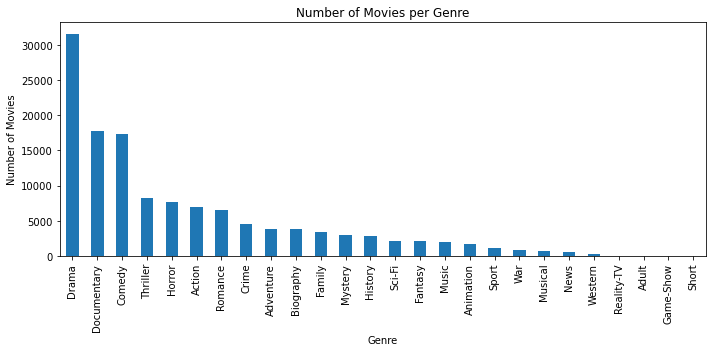

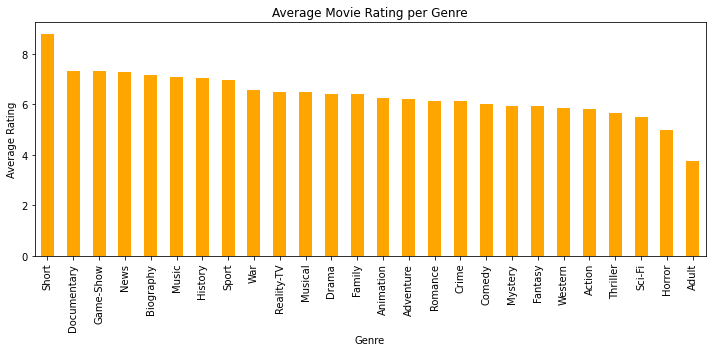

In [54]:
# Genre analysis: Count the number of movies per genre and average rating per genre
import matplotlib.pyplot as plt

# Split genres and explode to have one genre per row
genres_exploded = df_movie_basics_ratings.assign(
    genre=df_movie_basics_ratings['genres'].str.split(',')
).explode('genre')

# Count of movies per genre
genre_counts = genres_exploded['genre'].value_counts()

# Average rating per genre
genre_avg_rating = genres_exploded.groupby('genre')['averagerating'].mean().sort_values(ascending=False)

# Plot: Number of movies per genre
plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')
plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

# Plot: Average rating per genre
plt.figure(figsize=(10,5))
genre_avg_rating.plot(kind='bar', color='orange')
plt.title('Average Movie Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

In [55]:
# Calculate average movie ratings by genre using genres_exploded
avg_rating_by_genre = genres_exploded.groupby('genre')['averagerating'].mean().sort_values(ascending=False)

print("Average movie ratings by genre:")
print(avg_rating_by_genre)

Average movie ratings by genre:
genre
Short          8.800000
Documentary    7.332090
Game-Show      7.300000
News           7.271330
Biography      7.162274
Music          7.091972
History        7.040956
Sport          6.961493
War            6.584291
Reality-TV     6.500000
Musical        6.498336
Drama          6.403966
Family         6.394725
Animation      6.248308
Adventure      6.196201
Romance        6.146608
Crime          6.115441
Comedy         6.002689
Mystery        5.920401
Fantasy        5.919473
Western        5.868214
Action         5.810361
Thriller       5.639114
Sci-Fi         5.489755
Horror         5.003440
Adult          3.766667
Name: averagerating, dtype: float64


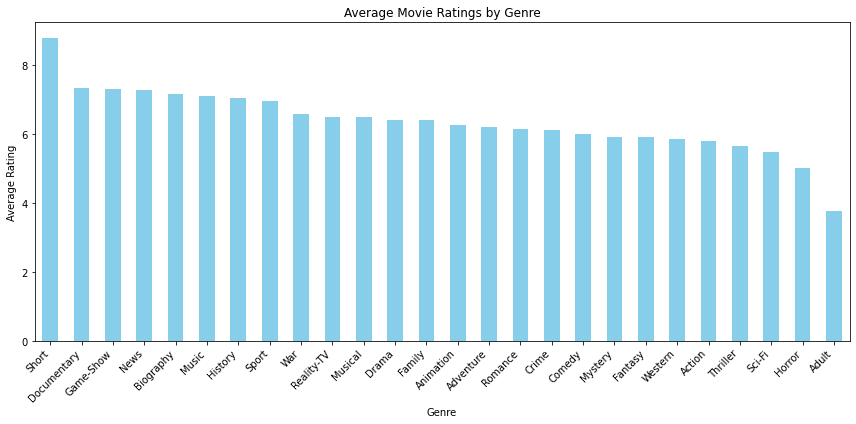

Top 5 genres by average rating:
genre
Short          8.800000
Documentary    7.332090
Game-Show      7.300000
News           7.271330
Biography      7.162274
Name: averagerating, dtype: float64

Bottom 5 genres by average rating:
genre
Adult       3.766667
Horror      5.003440
Sci-Fi      5.489755
Thriller    5.639114
Action      5.810361
Name: averagerating, dtype: float64


In [56]:
 #Visualize average movie ratings by genre
 plt.figure(figsize=(12, 6))
genre_avg_rating.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Average Movie Ratings by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display top 5 and bottom 5 genres by average rating
print("Top 5 genres by average rating:")
print(genre_avg_rating.sort_values(ascending=False).head(5))
print("\nBottom 5 genres by average rating:")
print(genre_avg_rating.sort_values().head(5))

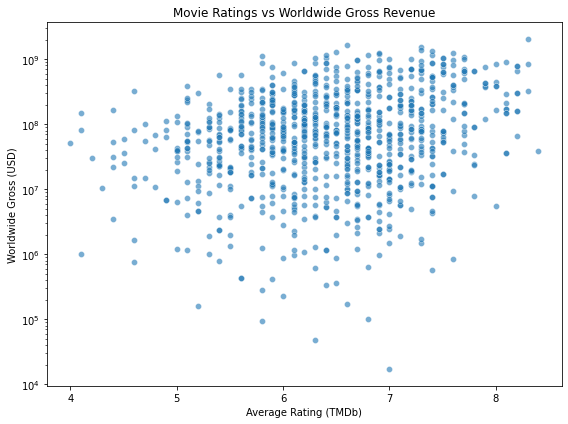

Correlation between average rating and worldwide gross: 0.29


In [57]:
import seaborn as sns

# Ratings vs Revenue Analysis

import matplotlib.pyplot as plt

# Prepare merged_data: convert 'worldwide_gross' and 'vote_average' to numeric
ratings_revenue = merged_data.copy()
ratings_revenue['worldwide_gross_num'] = ratings_revenue['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
ratings_revenue['vote_average'] = pd.to_numeric(ratings_revenue['vote_average'], errors='coerce')

# Drop rows with missing values in relevant columns
ratings_revenue = ratings_revenue.dropna(subset=['worldwide_gross_num', 'vote_average'])

# Scatter plot: Average Rating vs Worldwide Gross
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=ratings_revenue,
    x='vote_average',
    y='worldwide_gross_num',
    alpha=0.6
)
plt.title('Movie Ratings vs Worldwide Gross Revenue')
plt.xlabel('Average Rating (TMDb)')
plt.ylabel('Worldwide Gross (USD)')
plt.yscale('log')
plt.tight_layout()
plt.show()

# Calculate correlation
corr = ratings_revenue['vote_average'].corr(ratings_revenue['worldwide_gross_num'])
print(f"Correlation between average rating and worldwide gross: {corr:.2f}")

### Scatter Plot Interpretation:
The scatter plot of 'vote_average' (average movie rating) vs 'worldwide_gross_num' (worldwide gross revenue) shows a weak positive correlation (corr ≈ 0.29).
This means that, in general, movies with higher audience ratings tend to earn more at the box office, but the relationship is not strong.
#There are many highly rated movies with moderate revenue and some lower-rated movies with high revenue, indicating that other factors (like marketing, franchise, genre, etc.) also play a significant role in box office success.


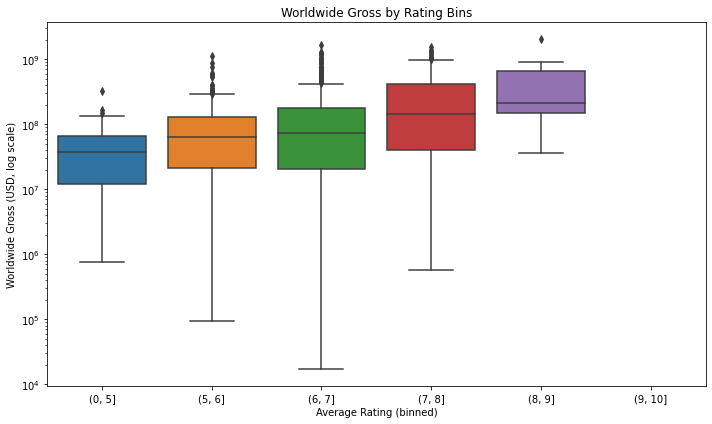

In [58]:
# Boxplot: Worldwide Gross grouped by Rating bins
ratings_revenue['rating_bin'] = pd.cut(ratings_revenue['vote_average'], bins=[0, 5, 6, 7, 8, 9, 10])
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=ratings_revenue,
    x='rating_bin',
    y='worldwide_gross_num'
)
plt.title('Worldwide Gross by Rating Bins')
plt.xlabel('Average Rating (binned)')
plt.ylabel('Worldwide Gross (USD, log scale)')
plt.yscale('log')
plt.tight_layout()
plt.show()

### Boxplot Interpretation:
The boxplot groups movies by rating bins and shows the distribution of worldwide gross within each bin.
While higher rating bins (e.g., 7-8, 8-9) tend to have higher median revenues, there is substantial overlap and variability within each bin.
Some movies with average or even low ratings can still achieve high box office revenue, and vice versa.
This further supports the idea that while ratings have some influence, they are not the sole determinant of box office performance.
